# Introduction



This notebook demonstrates how to use the `Synthesizer` code to generate photometry from cosmological galaxy formation simulations. We will explore how to load simulation data, calculate the stellar emission, include the effect of dust attenuation, and utilize simulation-based inference techniques to calibrate the dust model.

Throughout we use a simulation from the CAMELS suite as an example, but everything after data loading should be agnostic to the simulation shown.

## Install synthesizer

Installation instructions for synthesizer. Some of these instructions are needed to get this working on colab, please see the [documentation](https://synthesizer-project.github.io/synthesizer/) for the most up to date and simple install instructions for your machine.

Run everything up to *"Generating Photometry*" at the start of the session. Do not restart the session when prompted, just press cancel!

In [ ]:
%env SYNTHESIZER_DIR=/content

env: SYNTHESIZER_DIR=/content


In [ ]:
!WITH_OPENMP=1 pip install cosmos-synthesizer[test]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 84.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━

In [ ]:
!synthesizer-init

Synthesizer initialising...

                                     ⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣀⣀⡀⠒⠒⠦⣄⡀⠀⠀⠀⠀⠀⠀⠀                                     
                                     ⠀⠀⠀⠀⠀⢀⣤⣶⡾⠿⠿⠿⠿⣿⣿⣶⣦⣄⠙⠷⣤⡀⠀⠀⠀⠀                                     
                                     ⠀⠀⠀⣠⡾⠛⠉⠀⠀⠀⠀⠀⠀⠀⠈⠙⠻⣿⣷⣄⠘⢿⡄⠀⠀⠀                                     
                                     ⠀⢀⡾⠋⠀⠀⠀⠀⠀⠀⠀⠀⠐⠂⠠⢄⡀⠈⢿⣿⣧⠈⢿⡄⠀⠀                                     
                                     ⢀⠏⠀⠀⠀⢀⠄⣀⣴⣾⠿⠛⠛⠛⠷⣦⡙⢦⠀⢻⣿⡆⠘⡇⠀⠀                                     
                                   ⠀⠀⠀+-+-+-+-+-+-+-+-+-+-+-+⡇⠀⠀                                    
                                   ⠀⠀⠀|S|Y|N|T|H|E|S|I|Z|E|R|⠃⠀⠀                                    
                                   ⠀⠀⢰+-+-+-+-+-+-+-+-+-+-+-+⠀⠀⠀                                    
                                     ⠀⠀⢸⡇⠸⣿⣷⠀⢳⡈⢿⣦⣀⣀⣀⣠⣴⣾⠟⠁⠀⠀⠀⠀⢀⡎                                     
                                     ⠀⠀⠘⣷⠀⢻⣿⣧⠀⠙⠢⠌⢉⣛⠛⠋⠉⠀⠀⠀⠀⠀⠀⣠⠎

Download synthesizer test data

In [ ]:
!synthesizer-download --test-grids --destination grids/.

201MB [00:03, 55.0MB/s]
19.6MB [00:00, 28.1MB/s]
19.6MB [00:00, 27.2MB/s]


Install LtU-ILI

In [ ]:
!git clone https://github.com/maho3/ltu-ili.git

Cloning into 'ltu-ili'...
remote: Enumerating objects: 3704, done.
remote: Counting objects: 100% (922/922), done.
remote: Compressing objects: 100% (465/465), done.
remote: Total 3704 (delta 664), reused 482 (delta 456), pack-reused 2782 (from 2)
Receiving objects: 100% (3704/3704), 65.30 MiB | 19.02 MiB/s, done.
Resolving deltas: 100% (2328/2328), done.


In [ ]:
cd ltu-ili/

/content/ltu-ili


In [ ]:
!pip install ".[pytorch]"

Processing /content/ltu-ili
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/maho3/tarp.git to /tmp/pip-install-izr0lh5g/tarp_07e26d8efe1742059e1321300ddb2020
  Running command git clone --filter=blob:none --quiet https://github.com/maho3/tarp.git /tmp/pip-install-izr0lh5g/tarp_07e26d8efe1742059e1321300ddb2020
  Resolved https://github.com/maho3/tarp.git to commit 3fc2bfd0280b6239f8e367b7789fb4df8a907e33
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.0/150.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.0/460.0 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 840.8 kB/s eta 0:

In [ ]:
cd ../

/content


In [ ]:
!pip install schwimmbad

Download CAMELS simulation data.


In [ ]:
sim = 'SIMBA'  # 'Swift-EAGLE'

snapshot_url = f"https://users.flatironinstitute.org/~camels/Sims/{sim}/L25n256/CV/CV_1/snapshot_082.hdf5"
subfind_url = f"https://users.flatironinstitute.org/~camels/Sims/{sim}/L25n256/CV/CV_1/groups_082.hdf5"

!wget {snapshot_url}
!wget {subfind_url}

!ls

--2026-01-09 09:33:52--  https://users.flatironinstitute.org/~camels/Sims/SIMBA/L25n256/CV/CV_1/snapshot_082.hdf5
Resolving users.flatironinstitute.org (users.flatironinstitute.org)... 158.106.193.205
Connecting to users.flatironinstitute.org (users.flatironinstitute.org)|158.106.193.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1781270475 (1.7G) [application/octet-stream]
Saving to: ‘snapshot_082.hdf5’

snapshot_082.hdf5   100%[===================>]   1.66G   127MB/s    in 15s     

2026-01-09 09:34:08 (110 MB/s) - ‘snapshot_082.hdf5’ saved [1781270475/1781270475]

--2026-01-09 09:34:08--  https://users.flatironinstitute.org/~camels/Sims/SIMBA/L25n256/CV/CV_1/groups_082.hdf5
Resolving users.flatironinstitute.org (users.flatironinstitute.org)... 158.106.193.205
Connecting to users.flatironinstitute.org (users.flatironinstitute.org)|158.106.193.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 59734544 (57M) [application/octet-

# Generating photometry

We first load the CAMELS simulation data into synthesizer. We do this with a dedicated method for IllustrisTNG


In [ ]:
from synthesizer.load_data.load_camels import load_CAMELS_Simba, load_CAMELS_SwiftEAGLE_subfind
from synthesizer.conversions import lnu_to_absolute_mag
from synthesizer.emission_models import IncidentEmission
from synthesizer.instruments import FilterCollection

# Assuming the files are in the current directory
snapshot_path = 'snapshot_082.hdf5'
subfind_path = 'groups_082.hdf5'

gals = load_CAMELS_Simba(
# gals = load_CAMELS_SwiftEAGLE_subfind(
    './',
    snap_name=snapshot_path,
    group_name=subfind_path
)

/usr/local/lib/python3.12/dist-packages/unyt/array.py:1972: RuntimeWarning: invalid value encountered in divide
  out_arr = func(


/tmp/ipython-input-2223104671.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(mstar), np.log10(sfr))


Text(0, 0.5, '$\\rm log_{10}(SFR \\,/\\, M_{\\odot} \\, yr^{-1})$')

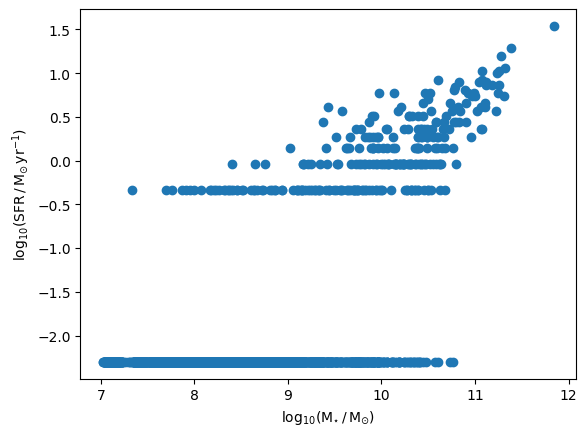

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from unyt import Myr

mstar = np.array([g.stellar_mass for g in gals])
sfr = np.array([g.stars.get_sfr(timescale=50*Myr) for g in gals])

sfr[sfr == 0] = 5e-3  #* np.random.rand(np.sum(sfr==0))

plt.scatter(np.log10(mstar), np.log10(sfr))
plt.xlabel(r"$\rm log_{10}(M_{\star} \,/\, M_{\odot})$")
plt.ylabel(r"$\rm log_{10}(SFR \,/\, M_{\odot} \, yr^{-1})$")

We now load a grid. [Grids](https://synthesizer-project.github.io/synthesizer/emission_grids/grids.html) are an important concept in Synthesizer, that describe the emission from some source (stellar, AGN, etc.) as a fucntion of some simple axes. In this case, we load a test grid provided with synthesizer, based on the BPASS v2.2.1 binary stellar population synthesis models.

In [ ]:
from unyt import angstrom
from synthesizer.grid import Grid

grid_name = "test_grid"
grid = Grid(grid_name)

print(grid)

+-----------------------------------------------------------------------------------+
|                                       GRID                                        |
+-----------------------------+-----------------------------------------------------+
| Attribute                   | Value                                               |
+-----------------------------+-----------------------------------------------------+
| grid_dir                    | '/content/grids'                                    |
+-----------------------------+-----------------------------------------------------+
| grid_name                   | 'test_grid'                                         |
+-----------------------------+-----------------------------------------------------+
| grid_ext                    | 'hdf5'                                              |
+-----------------------------+-----------------------------------------------------+
| grid_filename               | '/content/grids/test_g

[Emission models](https://synthesizer-project.github.io/synthesizer/emission_models/emission_models.html) are another important concept in Synthesizer, that describe how simulation properties are mapped to emissions. Emission models consist of four main operations: *extraction*, *generation*, *transformation* and *combination*, that can be combined to form arbitrarily complex models. Below we use a very simple premade model, *IncidentEmission*, that just extracts the incident emission directly from a grid.

In [ ]:
incident = IncidentEmission(grid)
print(incident)

|====== EmissionModel: incident ======|
|-------------------------------------|
|  INCIDENT (stellar)                 |
|-------------------------------------|
|Extraction model:                    |
|  Grid: test_grid                    |
|  Extract key: incident              |
|  Use velocity shift: False          |
|  Save emission: True                |
|=====================================|


We now combine these ingredients to generate some spectra. We first filter our galaxies by stellar mass, then call the `get_spectra` method on the Stars component on each galaxy, extracting the rest-frame luminosity stored on the `lnu` attribute.

In [ ]:
# Filter by stellar mass
mstar_mask = np.array([np.sum(g.stars.masses) > 1e9 for g in gals])
gals = [g for g, _m in zip(gals, mstar_mask) if _m]
len(gals)

specs = [g.stars.get_spectra(incident, nthreads=1) for g in gals]

Let's visualise some of these spectra, using the `plot_spectra` method on a galaxy object.

(1e+24, 1e+31)

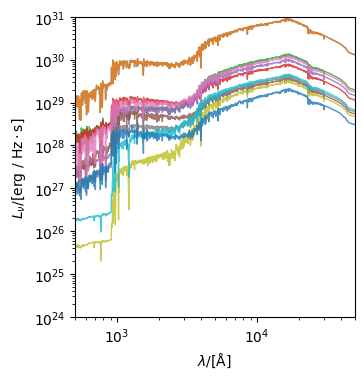

In [ ]:
fig, ax = specs[0].plot_spectra()
for i in np.arange(10):
  specs[i].plot_spectra(fig=fig, ax=ax)

ax.set_xlim(5e2, 5e4)
ax.set_ylim(1e24, 1e31)

We now use these spectra to generate photometry. We first load some filters, downloaded directly from the SVO [database](https://svo2.cab.inta-csic.es/theory/fps/index.php), then call the `get_photo_lnu` method on each galaxy Stars component. Finally, we convert this photometry from spectral luminosity units to absolute magnitudes. We don't necessarily have to use the spectra returned in `specs`, but this can be useful, as we will demonstrate below.

In [ ]:
filter_codes = [f"SLOAN/SDSS.{f}" for f in ["g", "r"]]
fc = FilterCollection(filter_codes=filter_codes, new_lam=grid.lam)

In [ ]:
# Calculate g-band magnitudes
phot = np.vstack(
    [g.stars.get_photo_lnu(fc)["incident"]["SLOAN/SDSS.g"] for g in gals]
)
mags = lnu_to_absolute_mag(phot)

We can now plot our g-band luminosity function.

In [ ]:
def calc_df(x, volume, binLimits):
    hist, dummy = np.histogram(x, bins=binLimits)
    hist = np.float64(hist)
    phi = (hist / volume) / (binLimits[1] - binLimits[0])

    phi_sigma = (np.sqrt(hist) / volume) / (
        binLimits[1] - binLimits[0]
    )  # Poisson errors

    return phi, phi_sigma, hist

h = 0.677

# Calculate g-band luminosity function
binlims = np.linspace(-25, -16, 12)
bins = binlims[:-1] + (binlims[1] - binlims[0]) / 2
phi, phi_sigma, _ = calc_df(mags, (25 / h) ** 3, binlims)

(-18.0, -24.0)

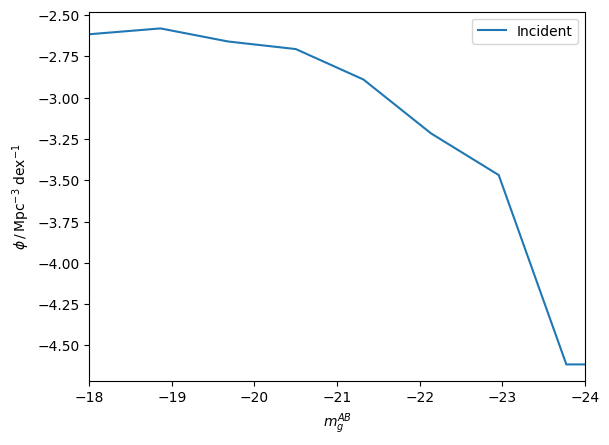

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
ax.plot(bins, np.log10(phi), label="Incident")
ax.legend()
ax.set_xlabel("$m_{g}^{AB}$")
ax.set_ylabel(r"$\phi \,/\, \mathrm{Mpc^{-3} \; dex^{-1}}$")
ax.set_xlim(-18, -24)

# Can we speed this up?

The main limitation on the speed of the spectra calculation is the resolution of the wavelength grid. We can resample our grid to only include the wavelengths we are interested in, here the rest-frame optical, $3000 < \lambda \,/\, Å < 10000$

In [ ]:
mask = (grid.lam > 3000 * angstrom) & (grid.lam < 1e4 * angstrom)
grid.interp_spectra(new_lam=grid.lam[mask])

/tmp/ipython-input-1471203506.py:2: RuntimeWarning: 
106 lines are outside the wavelength range of the grid and will be removed.
  grid.interp_spectra(new_lam=grid.lam[mask])


In [ ]:
incident = IncidentEmission(grid)
specs = [g.stars.get_spectra(incident, nthreads=1) for g in gals]

# What about dust?

If we want to include dust we simply need to update our emission model. Below, we add a transformation emission model component, `StellarEmissionModel`, to apply a power law dust curve with a fixed optical depth. We print this model, and plot the tree; this is still a very simple model, with only an extraction and transformation, so the tree only consists of two leaves connected by a dashed line.

|===================================== EmissionModel: attenuated =====================================|
|-----------------------------------------------------------------------------------------------------|
|  INCIDENT (stellar)                                                                                 |
|-----------------------------------------------------------------------------------------------------|
|Extraction model:                                                                                    |
|  Grid: test_grid                                                                                    |
|  Extract key: incident                                                                              |
|  Use velocity shift: False                                                                          |
|  Save emission: False                                                                               |
|---------------------------------------------------------------

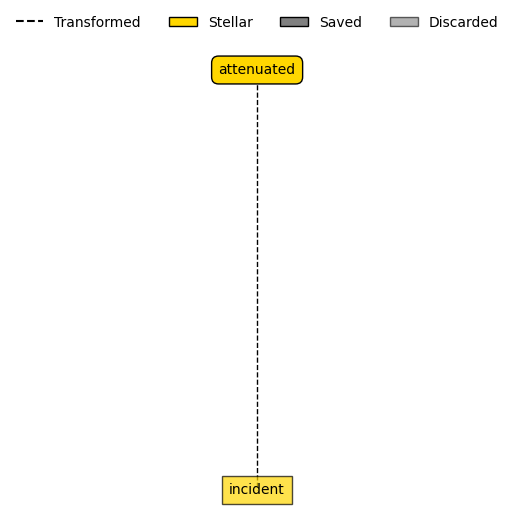

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [ ]:
from synthesizer.emission_models import StellarEmissionModel
from synthesizer.emission_models.attenuation import PowerLaw

incident = StellarEmissionModel(
    "incident",
    grid=grid,
    extract="incident",
    emitter="stellar",
    save=False,
)

attenuated = StellarEmissionModel(
    "attenuated",
    dust_curve=PowerLaw(slope=-1),
    apply_to=incident,
    tau_v=0.33
)
print(attenuated)
attenuated.plot_emission_tree()

To generate new spectra, we just pass this new emission model to the `get_spectra` method.

In [ ]:
specs_attenuated = [g.stars.get_spectra(attenuated, nthreads=4) for g in gals]

phot = np.vstack(
    [g.stars.get_photo_lnu(fc)["attenuated"]["SLOAN/SDSS.g"] for g in gals]
)
mags = lnu_to_absolute_mag(phot)

phi_att, phi_att_sigma, _ = calc_df(mags, (25 / h) ** 3, binlims)

/tmp/ipython-input-671831000.py:4: RuntimeWarning: divide by zero encountered in log10
  ax.plot(bins, np.log10(phi_att), label="Attenuated")


(-18.0, -24.0)

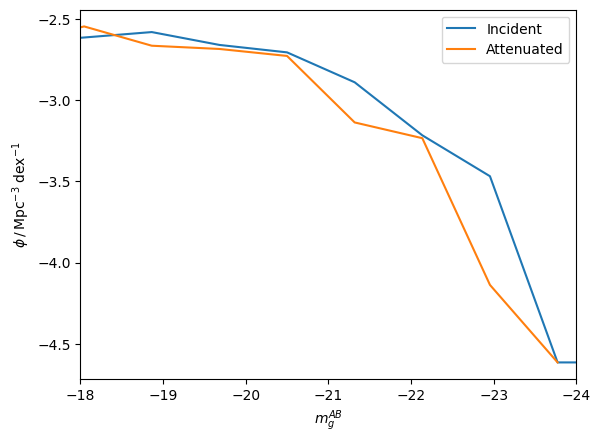

In [ ]:
fig, ax = plt.subplots(1, 1)

ax.plot(bins, np.log10(phi), label="Incident")
ax.plot(bins, np.log10(phi_att), label="Attenuated")

ax.legend()
ax.set_xlabel("$m_{g}^{AB}$")
ax.set_ylabel(r"$\phi \,/\, \mathrm{Mpc^{-3} \; dex^{-1}}$")
ax.set_xlim(-18, -24)

## Changing the SPS model

We can test how sensitive our results are to various ingredients in our model. We will show this by swapping out the Stellar Population Synthesis (SPS) model.

First we need to download a new grid. We have processed a number of these grids, and they are available on **Box** [here](https://sussex.app.box.com/v/SynthesizerProductionGrids/folder/316833654105). You should also be able to run the cell below, which should download a BC03 grid to the current directory.

In [ ]:
!wget --header 'Host: euc1.boxcloud.com' --user-agent 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:146.0) Gecko/20100101 Firefox/146.0' --header 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8' --header 'Accept-Language: en-GB,en;q=0.5' --referer 'https://sussex.app.box.com/' --header 'Cookie: b=2ca4d03e1f54b84ecf90f420102ca608c11057d9acc4672d3540112ca87a5f89' --header 'Upgrade-Insecure-Requests: 1' --header 'Sec-Fetch-Dest: iframe' --header 'Sec-Fetch-Mode: navigate' --header 'Sec-Fetch-Site: cross-site' --header 'Sec-Fetch-User: ?1' 'https://euc1.boxcloud.com/d/1/a1!BBBzxb5247ZCU5Pm2Sk2UyL0qW7WGQn17U2VpV3gHoutzZhGLkd9anHmAuHaNQVk1JE7rDDZmSsAweIr_cGWHjPAJ7XLoZv0T5EFxZAl7T_LlV28RznvlxDexN3-XqfivNjo3J_ga_1VOpoztMstPnxunl_0ddReMatPs9Fhsv3Z-8sJGA6g-7-Uwc5gxr2G9ZBqTPXOGmQZL6NsXXQhO7e5fvtZTB84k-iBkL0Wgwagikl55gibrBMUl2lBerFxmjh-9iuTizQgSgRcoqh2TgUCOm-QXgtP6uF0yFbCG4YdNV5UHmGMAjjUx8Iz9lHw178u1AuOkIAMDbLXxDPjqKdqRVWvA9uKa1iKESLFvCI6JnPnOpThW0RpXkmTAcW1G8opH2i56YagVGxtQS0kiMcbZh0xaZ40u8YyAgm5KzorF9l-s9k-D7c2Uhf39Sdl8BUEMQgAkYHaSXsH_JFdz1mQT8u2Ra4nqxq2JYCefrIi4WU0YMoeKQbA8Ehi0wkSo5dYWDkn4ob_dXCckhDOeIOlFo-_Z2Wnwd2d5WHlIaDktxEssyWsQcDKkAnBslmETB6uTcq3w8eyR0_dLjYZfj-VDZGGTet5MEWiT7HFA6QoQoD56eudwJxOB3KP8z9yr4GmhfD751YTpJfWRNbtOpmK7OyRAvYhwT4XEJJ96NJTRbWJmq0C24un70Z0Y0-d7GQbNfSGzVI9KT7qk2cYzxS3uZzn9IzJsTEAveU1U9OEzvM6G0WUqiAYJnvlJRu-18oiNONDxrI-Wlg1zUwsjta-7TbR-54QrXV8T-sJHjnJ8C2-8CrC0K3N8Ezz0baMEXQh5OZ7p8PWS0y2lYOEy4nJ0z40dpBXBmAWHeVsBqIQFTP75YvysmSNvV1NU4tBJV9JnK09AWStKl6Sn7SsdklG1Qcb1s_N-HrLoqxzCwUbQR3kZ-Hp2nAeySHskzkxBORtazumyyKsSCgF1GJOZar4S8HbHaVNO2XJJsHV5v7lXjTMFLdqDZqPqlVh_F_AgUG4odDf_l2cnjGbULuWtbwXOucm05JnJMy4Muroq9y7mSzT8tOiF3Yv0iXAJIwftq4DZY0v-he1dkXQ8eY_Vn3fUf-mCGm40vWRG2HTbIlztBO-lFaKKnSWSMFRx-Jm8XqmsP6b1s4EsVJvKCIrIA3tNEoEKJ7UPB_kp1pgbnWH_7ULhlraFs--W5irUdl6n7GQ0vvXPf0JP8HGBPlsfIQ9kgw14U2RdV5JjYi7WInIwZz6Wi5_2ebCybD10xVOPAP_grQ7PCD83Iptv4YpySBGdrBeoBmzivu4KekAac3bNtGrIFHde6M9aHL59Njk6CstTsvG7BkNTvTXZWHjsCMn8lV8RPSxIwknjSIRM5Th2qh7HuoE96sI2x_csgy9-j_wbhlinqWd-QOQcAg4ZcaD0Yj0_mJJDICjOCVdFK7jpgEIBngCYePJZ6pirepvXIg-n3LLVHU4WRSekgJj5wEYHPPamnXJo8glQKEHF1DKGw../download' --output-document 'grids/bc03-2016-Miles_chabrier-0.1,100_cloudy-c23.01-sps.hdf5'

--2026-01-09 09:36:18--  https://euc1.boxcloud.com/d/1/a1!BBBzxb5247ZCU5Pm2Sk2UyL0qW7WGQn17U2VpV3gHoutzZhGLkd9anHmAuHaNQVk1JE7rDDZmSsAweIr_cGWHjPAJ7XLoZv0T5EFxZAl7T_LlV28RznvlxDexN3-XqfivNjo3J_ga_1VOpoztMstPnxunl_0ddReMatPs9Fhsv3Z-8sJGA6g-7-Uwc5gxr2G9ZBqTPXOGmQZL6NsXXQhO7e5fvtZTB84k-iBkL0Wgwagikl55gibrBMUl2lBerFxmjh-9iuTizQgSgRcoqh2TgUCOm-QXgtP6uF0yFbCG4YdNV5UHmGMAjjUx8Iz9lHw178u1AuOkIAMDbLXxDPjqKdqRVWvA9uKa1iKESLFvCI6JnPnOpThW0RpXkmTAcW1G8opH2i56YagVGxtQS0kiMcbZh0xaZ40u8YyAgm5KzorF9l-s9k-D7c2Uhf39Sdl8BUEMQgAkYHaSXsH_JFdz1mQT8u2Ra4nqxq2JYCefrIi4WU0YMoeKQbA8Ehi0wkSo5dYWDkn4ob_dXCckhDOeIOlFo-_Z2Wnwd2d5WHlIaDktxEssyWsQcDKkAnBslmETB6uTcq3w8eyR0_dLjYZfj-VDZGGTet5MEWiT7HFA6QoQoD56eudwJxOB3KP8z9yr4GmhfD751YTpJfWRNbtOpmK7OyRAvYhwT4XEJJ96NJTRbWJmq0C24un70Z0Y0-d7GQbNfSGzVI9KT7qk2cYzxS3uZzn9IzJsTEAveU1U9OEzvM6G0WUqiAYJnvlJRu-18oiNONDxrI-Wlg1zUwsjta-7TbR-54QrXV8T-sJHjnJ8C2-8CrC0K3N8Ezz0baMEXQh5OZ7p8PWS0y2lYOEy4nJ0z40dpBXBmAWHeVsBqIQFTP75YvysmSNvV1NU4tBJV9JnK09AWStKl6Sn7SsdklG1Qcb1s_N-HrLoqxzCwUbQR

In [ ]:
grid_name = "bc03-2016-Miles_chabrier-0.1,100_cloudy-c23.01-sps.hdf5"
# grid_name = "bc03-2016-Miles_chabrier-0.1,100.hdf5"
grid = Grid(grid_name)

OSError: Unable to synchronously open file (file signature not found)

This is a grid that has been reprocessed through CLOUDY, a photoionisation code that predicts the nebular line and continuum emission. As such, we have a number of additional attributes, spectra and also *lines* that we can explore. A summary of the fiducial naming system for these emissions is provided [here](https://synthesizer-project.github.io/synthesizer/emissions/emissions.html).

In [ ]:
grid.available_emissions

Let's update our emission model to use the *nebular* emission (including line and continuum emission).

In [ ]:
def intrinsicemissionmodel(grid):
  line = StellarEmissionModel(
      "line",
      grid=grid,
      extract="linecont",
      emitter="stellar",
      save=False,
  )

  cont = StellarEmissionModel(
      "cont",
      grid=grid,
      extract="nebular_continuum",
      emitter="stellar",
      save=False,
  )

  transmitted = StellarEmissionModel(
      "transmitted",
      grid=grid,
      extract="transmitted",
      emitter="stellar",
      save=False,
  )

  intrinsic = StellarEmissionModel(
      "intrinsic",
      combine=(line,cont,transmitted),
      save=True,
  )
  return intrinsic

intrinsic = intrinsicemissionmodel(grid)
attenuated = StellarEmissionModel(
    "attenuated",
    dust_curve=PowerLaw(slope=-1),
    apply_to=intrinsic,
    tau_v=0.33
)

In [ ]:
specs_bc03 = [g.stars.get_spectra(attenuated, nthreads=4) for g in gals[:10]]

In [ ]:
fig, ax = specs_bc03[0].plot_spectra()
for i in np.arange(1, 10):
  specs_bc03[i].plot_spectra(fig=fig, ax=ax)

ax.set_xlim(5e2, 5e4)
ax.set_ylim(1e25, 1e31)

Can clearly see that for some galaxies there are strong emission lines, including Lyman-$\alpha$.

We can also look at the emission from individual lines. These grids have a large number of different lines, following the CLOUDY naming convention, for which luminosities, equivalent widths and other properties are available.

In [ ]:
print(grid.available_lines)

In [ ]:
lc = grid.get_lines_for_full_grid('H 1 3734.37A')
plt.imshow(
    lc.get_flux0()[0],
    origin='lower',
    aspect='auto',
    extent=[
        grid.axes_values['metallicities'][0],
        grid.axes_values['metallicities'][-1],
        np.log10(grid.axes_values['ages'][0]),
        np.log10(grid.axes_values['ages'][-1])
    ]
)
plt.xlabel('Metallicity')
plt.ylabel(f'log10 Age')
plt.colorbar(label=f'Luminosity ({grid.line_lums["nebular"].units})')

We also provide functionality for producing common line diagnostic plots, such as the BPT diagram. Here we plot the values from the grid at fixed age, for a range of metallicities.

In [ ]:
from synthesizer.emissions import line_ratios

diagram_id = "BPT-NII"
ia = 0  # 1 Myr old for test grid
x = []
y = []
for iZ, Z in enumerate(grid.metallicity):
    grid_point = (ia, iZ)
    lines = grid.get_lines(grid_point)
    x_, y_ = lines.get_diagram(diagram_id)
    x.append(x_)
    y.append(y_)


# Plot the Kewley SF/AGN dividing line
fig, ax = plt.subplots()
ax.plot(x, y)
logNII_Ha = np.arange(-2.0, 1.0, 0.01)
logOIII_Hb = line_ratios.plot_bpt_kewley01(
    logNII_Ha, fig=fig, ax=ax, show=True, c="k", lw="2", alpha=0.3
)

Let's reduce the wavelength range again, and try reproducing the g-band luminosity function.

In [ ]:
mask = (grid.lam > 3000 * angstrom) & (grid.lam < 1e4 * angstrom)
grid.interp_spectra(new_lam=grid.lam[mask])

Update our attenuated emission model with our new grid.

In [ ]:
line = StellarEmissionModel(
    "line",
    grid=grid,
    extract="linecont",
    emitter="stellar",
    save=False,
)

cont = StellarEmissionModel(
    "cont",
    grid=grid,
    extract="nebular_continuum",
    emitter="stellar",
    save=False,
)

transmitted = StellarEmissionModel(
    "transmitted",
    grid=grid,
    extract="transmitted",
    emitter="stellar",
    save=False,
)

intrinsic = StellarEmissionModel(
    "intrinsic",
    combine=(line,cont,transmitted),
    save=True,
)

attenuated = StellarEmissionModel(
    "attenuated",
    dust_curve=PowerLaw(slope=-1),
    apply_to=intrinsic,
    tau_v=0.33
)

In [ ]:
specs_BC03 = [g.stars.get_spectra(attenuated) for g in gals]

phot = np.vstack(
    [g.stars.get_photo_lnu(fc)["attenuated"]["SLOAN/SDSS.g"] for g in gals]
)
mags = lnu_to_absolute_mag(phot)

phi_bc03, _, _ = calc_df(mags, (25 / h) ** 3, binlims)

fig, ax = plt.subplots(1, 1)
ax.plot(bins, np.log10(phi_bc03), label="BC03")
ax.plot(bins, np.log10(phi_att), label="BPASS")
ax.legend()
ax.set_xlabel("$m_{g}^{AB}$")
ax.set_ylabel(r"$\phi \,/\, \mathrm{Mpc^{-3} \; dex^{-1}}$")
ax.set_xlim(-18, -24)

# Calibrating the dust model

Can we fit some of these parameters in our dust model, such as the optical depth and slope of the attenuation law? Here we present a somewhat over engineered example, using Simulation Based Inference (SBI) to infer posteriors on these parameters, derived from our forward modelled data. SBI has a number of neat advantages over traditional inference approaches, utilising neural density estimators to directly model the relationship between data and parameters.

We will use the [LtU-ILI package](https://github.com/maho3/ltu-ili/tree/main) to build a Neural Posterior Estimation (NPE) model.

In [ ]:
import torch

import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

We create a slightly more complex emission model for this example, utilising a two component screen inspired by Charlot & Fall 2000. We start by precomputing the intrinsic spectra for young and old stars, where the division is made at 100 Myr.

In [ ]:
from synthesizer.emission_models import EmissionModel
from unyt import Myr


def intrinsicemissionmodel(grid, age_op='<'):
  line = StellarEmissionModel(
      "line"+age_op,
      grid=grid,
      extract="linecont",
      emitter="stellar",
      mask_attr="ages",
      mask_thresh=10 * Myr,
      mask_op=age_op,
      save=False,
  )

  cont = StellarEmissionModel(
      "cont"+age_op,
      grid=grid,
      extract="nebular_continuum",
      emitter="stellar",
      mask_attr="ages",
      mask_thresh=10 * Myr,
      mask_op=age_op,
      save=False,
  )

  transmitted = StellarEmissionModel(
      "transmitted"+age_op,
      grid=grid,
      extract="transmitted",
      emitter="stellar",
      mask_attr="ages",
      mask_thresh=10 * Myr,
      mask_op=age_op,
      save=False,
  )

  intrinsic = StellarEmissionModel(
      "intrinsic"+age_op,
      combine=(line,cont,transmitted),
      save=True,
  )
  return intrinsic

intrinsic_young = intrinsicemissionmodel(grid, '<')
intrinsic_old = intrinsicemissionmodel(grid, '>')

intrinsic = EmissionModel(
    label="intrinsic_combined",
    combine=(intrinsic_young, intrinsic_old),
    emitter="stellar",
)

specs = [g.stars.get_spectra(intrinsic, nthreads=1) for g in gals]

We then create a latin hypercube of four parameters, the ISM optical depth, the birth cloud optical depth, and the slope of the attenuation curve for the ISM and birth cloud dust.

In [ ]:
from scipy.stats import qmc
from tqdm import tqdm

sampler = qmc.LatinHypercube(d=4)
sample = sampler.random(n=100)

l_bounds = [0.1, 0.5, -2, -2]
u_bounds = [0.5, 1.0, -0.5, -0.5]
theta = qmc.scale(sample, l_bounds, u_bounds)

We now loop over these parameters, and calculate the photometry for each combination of parameters.

In [ ]:
phi_att = [None] * len(theta)
for i, _params in tqdm(enumerate(theta), total=len(theta)):
  for g in gals:
    int_young = g.stars.spectra['intrinsic<']
    int_old = g.stars.spectra['intrinsic>']

    att_young = int_young.apply_attenuation(tau_v=_params[0], dust_curve=PowerLaw(slope=_params[2]))
    att_old = int_old.apply_attenuation(tau_v=_params[1], dust_curve=PowerLaw(slope=_params[3]))
    g.stars.spectra['attenuated'] = att_young + att_old

  phot = np.vstack(
      [g.stars.get_photo_lnu(fc)["attenuated"]["SLOAN/SDSS.g"] for g in gals]
  )
  mags = lnu_to_absolute_mag(phot)
  phi_att[i], phi_att_sigma, _ = calc_df(mags, (25 / h) ** 3, binlims)

The figure below shows some of our example luminosity functions

In [ ]:
fig, ax = plt.subplots(1, 1)

ax.plot(bins, np.log10(phi_bc03), label="Fiducial")
ax.fill_between(bins, np.log10(np.percentile(phi_att, 10, axis=0)), np.log10(np.percentile(phi_att, 90, axis=0)), color='grey', alpha=0.6)

ax.legend()
ax.set_xlabel("$m_{g}^{AB}$")
ax.set_ylabel(r"$\phi \,/\, \mathrm{Mpc^{-3} \; dex^{-1}}$")
ax.set_xlim(-18, -24)

plt.show()

## Simulation Based Inference

We load our data x (binned luminosity function) and parameters theta, set our priors to be flat over the same range as the proposal distribution, and combine two Masked Autoregressive Flows (MAF) with a Mixture Density Network (MDN) to model the posterior. We set some hyperparameters for the training, such as batch size and learning rate. In a real science case we would optimise these parameters.

In [ ]:
# make a dataloader
loader = NumpyLoader(x=phi_att, theta=theta)

# define a prior
prior = ili.utils.Uniform(low=l_bounds, high=u_bounds, device=device)

# instantiate your neural networks to be used as an ensemble
repeats_maf = 2 # not to have to duplicate code for a large ensemble of identical architectures
nets = [
    ili.utils.load_nde_sbi(engine='NPE', model='maf', hidden_features=50, num_transforms=5, repeats = repeats_maf),
    ili.utils.load_nde_sbi(engine='NPE', model='mdn', hidden_features=50, num_components=6)
]

# define training arguments
train_args = {
    'training_batch_size': 32,
    'learning_rate': 1e-4
}

# initialize the trainer
runner = InferenceRunner.load(
    backend='sbi',
    engine='NPE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None,
    out_dir=None
)


In [ ]:
# train the model
posterior_ensemble, summaries = runner(loader=loader)

We can visualise our training curves to make sure we're not overfitting.

In [ ]:
import matplotlib.colors as mcolors

# plot train/validation loss
fig, ax = plt.subplots(1, 1, figsize=(6,4))
c = list(mcolors.TABLEAU_COLORS)
for i, m in enumerate(summaries):
    ax.plot(-1.0*np.array(m['training_loss']), ls='-', label=f"{i}_train", c=c[i])
    ax.plot(-1.0*np.array(m['validation_loss']), ls='--', label=f"{i}_val", c=c[i])
ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend()

We can now visualise our results predicting the posterior for a given simulation. We choose a random index (0) and generate our posterior, and compare to the true value.

In [ ]:
ind = 0

# use ltu-ili's built-in validation metrics to plot the posterior for this point
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=[f'$\\theta_{i}$' for i in range(4)]
)
fig = metric(
    posterior=posterior_ensemble,
    x_obs = phi_att[ind], theta_fid=theta[ind],
    plot_kws=dict(fill=True)
)

We can also generate some coverage and posterior predictive checks. These show how well our NPE is learning an unbiased and accurate representation of the posterior.

In [ ]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    labels=[f'$\\theta_{i}$' for i in range(4)],
    plot_list = ["coverage", "histogram", "predictions", "tarp", "logprob"],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble, # NeuralPosteriorEnsemble instance from sbi package
    x=phi_att, theta=theta
)

Let's sample from the posterior and show the range of predicted luminosity functions against the 'true' data.

In [ ]:
samples = posterior_ensemble.sample((100,), torch.Tensor(phi_att[ind]).to(device))

phi_samp = [None] * len(theta)
for i, _params in tqdm(enumerate(samples), total=len(samples)):
  for g in gals:
    int_young = g.stars.spectra['intrinsic<']
    int_old = g.stars.spectra['intrinsic>']

    att_young = int_young.apply_attenuation(tau_v=float(_params[0]), dust_curve=PowerLaw(slope=float(_params[2])))
    att_old = int_old.apply_attenuation(tau_v=float(_params[1]), dust_curve=PowerLaw(slope=float(_params[3])))
    g.stars.spectra['attenuated'] = att_young + att_old

  phot = np.vstack(
      [g.stars.get_photo_lnu(fc)["attenuated"]["SLOAN/SDSS.g"] for g in gals]
  )
  mags = lnu_to_absolute_mag(phot)
  phi_samp[i], phi_att_sigma, _ = calc_df(mags, (25 / h) ** 3, binlims)

In [ ]:
fig, ax = plt.subplots(1, 1)

ax.plot(bins, np.log10(phi_att[ind]), label="True")

for i in np.arange(len(phi_samp)):
  ax.plot(bins, np.log10(phi_samp[i]), ls='dashed', color='grey')

ax.legend()
ax.set_xlabel("$m_{g}^{AB}$")
ax.set_ylabel(r"$\phi \,/\, \mathrm{Mpc^{-3} \; dex^{-1}}$")
ax.set_xlim(-18, -24)

plt.show()

Can we improve the constraints on the slope by adding in colour information? Try adding in the $g-r$ colour to the data vector, and see how the posterior constraints improve.